# Analytical Aeroelasticity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# Rigid wing Load Alleviation

The objective is to find the optimal placement of an aileron for load alleviation. This is achieved thanks to an inboard redistribution of the lift through the movables.

A simple elliptical lift distribution with a point load applied as the contribution of the aileron, assuming that the point load is proportional to the elliptical lift distribution. Meaning the efficiency of the aileron will be greater closer to the root than at the tip.

$$ C_l (y) = \frac{\partial C_l}{\partial \alpha} \alpha \left[ \sqrt{1-\frac{y^2}{b^2}} + \frac{\partial C_l}{\partial \epsilon} \epsilon \sqrt{1-\frac{p^2}{b^2}} \right]$$

where $p$ is the position of the aileron, $\epsilon$ the aileron deflection.

To further simplify well assume a fixed aileron deflection and $ \frac{\partial C_l}{\partial \epsilon} \epsilon = - \eta_a $, it is negative as the deflection of the aileron is upward to generate load alleviation.

If we want to optimise the aileron position for minimum bending moment:

$$ \begin{align}
  {\rm Minimize}   && M_x(p) \nonumber \\
  {\rm w.r.t.}     && \text{p} \nonumber \\
  {\rm subject~to} && 0 < p/b < 1 \nonumber
\end{align} $$

The wing bending moment is defined as:

$$ M_x(y) = \frac{\partial C_l}{\partial \alpha} \alpha \left[ \int_y^b  \sqrt{1
-\frac{y^2}{b^2}}  y \partial y - \eta_a \sqrt{1-\frac{p^2}{b^2}}  p \right] \quad \quad(1)$$

Since the optimisation is respect to the position ($p$), the integral part dissapears. Computing the derivative gives:

$$ \frac{\partial M_x(y)}{\partial p} = - \frac{\partial C_l}{\partial \alpha} \alpha \eta_a \frac{b^2 -2p^2}{b^2 \sqrt{1- (p/b)^2}}  $$

Which gives the optima:

$$ p = \frac{b}{\sqrt{2}} \approx 0.71\ b $$

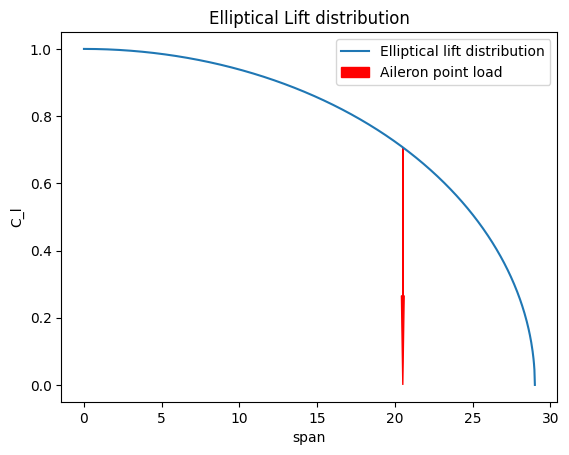

<ipython-input-481-f8c7777287b4>:42: RuntimeWarning: divide by zero encountered in scalar divide
  m_x_1[i] = (b**2 - 2*p_i**2)/(b**2 * np.sqrt(1-p_i**2/b**2) )


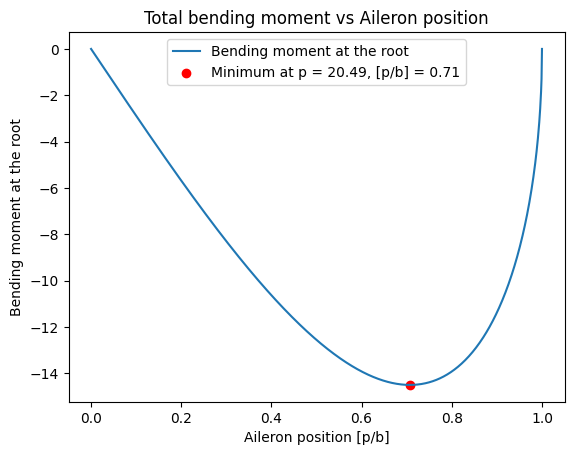

In [ ]:
# Ellipse parameters
b = 29 # span

# Generate points for the ellipse
x = np.linspace(0, b, 1000)
y = np.sqrt(1 - (x**2/b**2))

# Plot the ellipse
plt.plot(x, y, label='Elliptical lift distribution')

# Arrow parameters
arrow_start_x = b/np.sqrt(2)  # Example of aileron placement
arrow_start_y = np.sqrt(1 - (arrow_start_x**2 / b**2))
arrow_size = np.sqrt(1 - (arrow_start_x**2 / b**2))  # Length of the arrow

# Draw an arrow
plt.arrow(arrow_start_x, arrow_start_y, 0, -arrow_size, head_width=0.25*arrow_size,
          length_includes_head=True, fc='red', ec='red',
          label='Aileron point load')

# Additional plot formatting
plt.xlabel('span')
plt.ylabel('C_l')
plt.title('Elliptical Lift distribution')
plt.legend()
#plt.grid(True)
#plt.axis('equal')  # Ensure equal scaling for both axes
plt.show()

# Plot the bending moment as a function of the aileron placement

p = np.linspace(0, b, 1000) # Aileron placement

m_x = np.zeros(len(p)) # Bending moment as a function of aileron placement
m_x_1 = m_x.copy()


for i, p_i in enumerate(p):
    # Bending moment as a function of aileron placement
    m_x[i] = - np.sqrt(1-(p_i**2/b**2)) * p_i
    # Derivative Bending moment as a function of aileron placement
    m_x_1[i] = (b**2 - 2*p_i**2)/(b**2 * np.sqrt(1-p_i**2/b**2) )

plt.plot(p/b, m_x, label='Bending moment at the root')
#plt.plot(p, m_x_1/np.max(m_x_1), label='Elliptical lift distribution')
plt.title('Total bending moment vs Aileron position')

# Mark the minimum
min_index_2 = np.argmin(m_x)
minMx_x, minMx_y = p[min_index_2], m_x[min_index_2]
plt.scatter(minMx_x/b, minMx_y, color='red',
            label=f'Minimum at p = {minMx_x:.2f}, [p/b] = {minMx_x/b:.2f}')
plt.legend()
plt.xlabel('Aileron position [p/b]')
plt.ylabel('Bending moment at the root')
plt.show()


## Trim effects

This first demonstration shows that the optima for load reduction in a fixed angle of attack (AoA). But, for the problem to be fully defined we must conserve the total lift equal to the weigth $ L = W $. This means that the loss in lift due to the aileron must be compensated with a greater AoA. Then the problem becomes:
$$ \begin{align}
  {\rm Minimize}   && M_x(p) \nonumber \\
  {\rm w.r.t.}     && \text{p} \nonumber \\
  {\rm subject~to} && 0 < p/b < 1 \nonumber \\
  {\rm and} && L(\alpha) = W \nonumber
\end{align} $$

But, since we defined an elliptical lift distribution, the total load, in equation (1) increasing the angle of attack will not change whatsoever the optimal position for the aileron. Which means that even if we satisfy the new constraint we will not get a different result.

# Elastic wing

Now that we have already demonstrated that for a rigid wing with elliptic lift distribution the optimal placement for loads reduction lies at $b/\sqrt{2}$. The next challenge lies on trying to demonstrate the same for an elastic wing.

From Book T.H.G. Megson Aircraft Structures for Engineering Students:

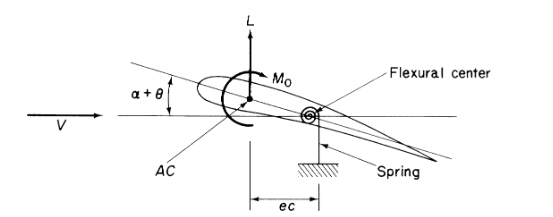

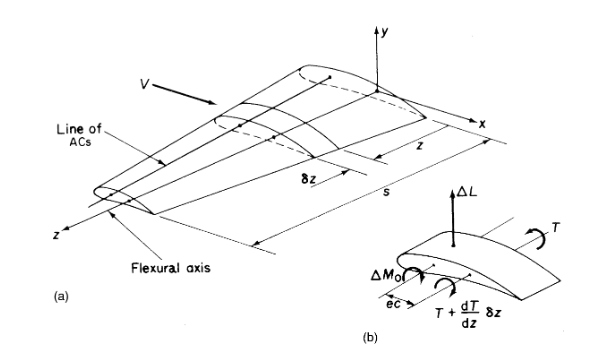

> <div class="alert alert-block alert-warning">
<b>Warning:</b> I've changed the reference coordinate system to match aircraft GFEM. X-axis chordwise, Y-axis spanwise, Z-axis up.
</div>



Chapter 29 Wing problems

- Eq. (29.4):

$$GJ \frac{d²\theta(y)}{dy²} + \frac{dL}{dy} ec + \frac{dM_0}{dy} = 0$$

$$\Delta L = \frac{1}{2} \rho V^2 c \frac{\partial c_l}{\partial \alpha}(\alpha + \theta) \delta y$$
$$\Delta M_0 = \frac{1}{2} \rho V^2 c^2 c_{m,0} \delta y$$

- Eq. (29.6): $$\frac{ d^{2} \theta(y)}{dy^2} + \frac{\frac{1}{2}\rho V^{2} ec^{2} (\partial c_l / \partial \alpha)}{GJ}\theta(y) = -\frac{\frac{1}{2}\rho V^{2}ec^{2}(\partial c_{l}/ \partial \alpha)}{GJ} \alpha - \frac{\frac {1}{2}\rho V^ {2}c^ {2}}{GJ}c_ {m,0}$$

where: $$ \lambda^2 = \frac{1/2 \rho V^2 ec^2 (\partial c_l/ \partial \alpha)}{GJ}$$

Leading to (2):

$$\frac{ d^{2} \theta(y)}{dy^2} + \lambda^2 \theta = -\lambda^2 \left[\alpha + \frac{c_ {m,0}}{(\partial c_l / \partial \alpha) e} \right] \quad \quad (2)$$

Further simplified by:

$$\frac{ d^{2} \theta(y)}{dy^2} + \lambda^2 \theta = -\lambda^2 (\alpha + \gamma)$$

Which solution is given by Eq. (29.9) with b.c. $\theta(y=0) = 0$ and $ \theta'(y=b) = 0$ :

$$ \theta(y) = \left[\alpha + \frac{c_{m,0}}{e(\partial c_l / \partial \alpha)}\right] \left[ \frac{cos( \lambda(b - y))}{cos(\lambda b)} - 1 \right] $$

or:

$$ \theta(y) = (\alpha + \gamma) \left[ \frac{cos( \lambda(b - y))}{cos(\lambda b)} -1 \right] $$

$$ \theta(y) = \lambda(\alpha + \gamma) \frac{sin( \lambda(b - y))}{cos(\lambda b)} $$

This equation assumes constant $(\partial c_l/ \partial \alpha ) $ along the span.

In [ ]:
# Define boundary conditions,
# y[0] = 0 == y(x=0) = 0 and y[1] = 0 == y'(x = b) = 0
def bc(ya, yb):
    return np.array([ya[0], yb[1]])

# Integration domain
x_values = np.linspace(0, b, 100)

# Define the range of y values for the solution
y_values = np.zeros((2,x_values.size))  # Change as needed

Define numerical integration ODE

Eq. (2) will be further simplified to:

$$\frac{ d^{2} \theta(y)}{dy^2} = -\lambda^2 (\alpha + \theta(y) + \gamma)$$

In [ ]:
# Wing semi-span
b = 29 # [m]

# Angle of attack
alpha = 0.1

# Lambda =! n*b*pi/2 where n = 1,2,3...
# Dynamic Pressure * ec² * dclda / GJ [Aero-flex factor]
# For positive twist (pitch-up), lambda * b < pi/2
lambd = 0.3 * (np.pi/2)/b

# cm0/dclda*e
gamma = -0.02

def ode_system_clean_cteL(x, y):
    rhsEq = -lambd**2*(y[0] + alpha + gamma)
    return np.vstack((y[1], rhsEq))

result_clean_simpl = solve_bvp(ode_system_clean_cteL, bc, x_values, y_values)

## Verify that the solution matches the ode solved by python:

Plot the twist function and its derivative compared to the analytical solution

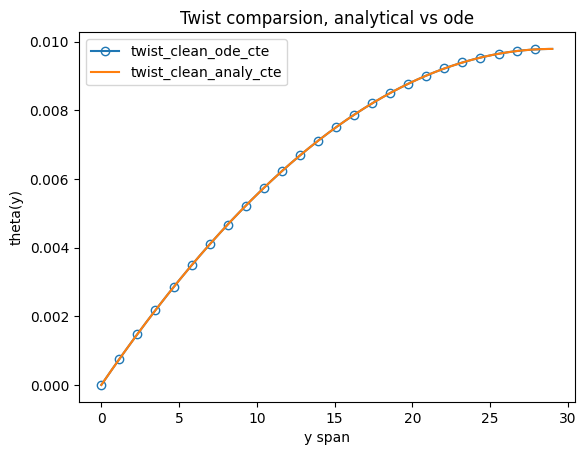

In [ ]:
x_plot = np.linspace(0, b, 1000)

def theta_wing_analy(x):
    return (alpha + gamma)*((np.cos(lambd*(b-x)))/np.cos(lambd*b) - 1)

def deriv_theta_wing_analy(x):
    return lambd*(alpha + gamma)*(np.sin(lambd*((b-x)))/np.cos(lambd*b))

# Plot ode
plt.plot(x_plot, result_clean_simpl.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_cte', markevery=40, markerfacecolor='none')

# Plot analytical
plt.plot(x_plot, theta_wing_analy(x_plot),
         label='twist_clean_analy_cte')

plt.title('Twist comparsion, analytical vs ode')
plt.xlabel('y span')
plt.ylabel('theta(y)')
plt.legend()
#plt.plot(x_plot, result_clean_simpl.sol(x_plot)[1], label='twist\' clean const')

### Including elliptical distribution

Now to include the elliptical lift distribution,  $ c_l(y) = \sqrt{1-y^2/b^2} $ equation (1) is further modified to (2):

$$\frac{ d^{2} \theta(y)}{dy^2} = - \lambda^2 (\alpha + \theta(y) + \gamma) \sqrt{1- y^2 / b^2}$$

Which cannot be solved analitycally (as far as I know), but numerically we can show its shape.

In [ ]:
# Again lambda = gamma = alpha = 1
def ode_system_clean_ellip(x, y):
    rhsEq = -lambd**2*(y[0] + alpha + gamma)*np.sqrt(1-(x**2)/(b**2))
    return np.vstack((y[1], rhsEq))

result_clean_ellip = solve_bvp(ode_system_clean_ellip, bc, x_values, y_values)

## Comparing the constant and elliptical lift distribution effect on twist

Plotting twist with and without elliptical distribution

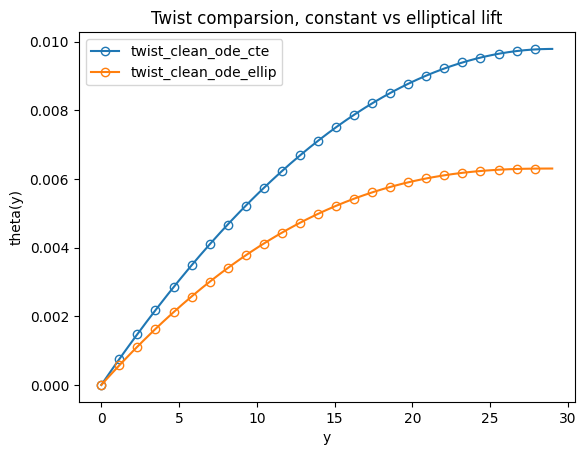

In [ ]:
# Plot clean constant lift twist (y)
plt.plot(x_plot, result_clean_simpl.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_cte', markevery=40, markerfacecolor='none')

# Plot clean elliptical lift twist (y)
plt.plot(x_plot, result_clean_ellip.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_ellip', markevery=40, markerfacecolor='none')

plt.title('Twist comparsion, constant vs elliptical lift')
plt.xlabel('y')
plt.ylabel('theta(y)')
plt.legend()

## Twist approximation correction

> <div class="alert alert-block alert-info">
<b>Problem:</b> Introducing an elliptical lift distribution complexifies significantly the equation</div>

In order to be able to solve the equation analitically, it is possible approximate the function (2), remplacing $\sqrt{1- y^2}$ with a constant of known value $\Theta$, wich approximates the twist.

$$ \theta(y) = \Theta (\alpha + \gamma) \left[ \frac{cos( \lambda (b - y))}{cos(\lambda  b)} -1 \right] $$

This value $\Theta$ is not constant with respect to $\lambda$ so for the time being the twist approximation will be made with constant lift distribution.

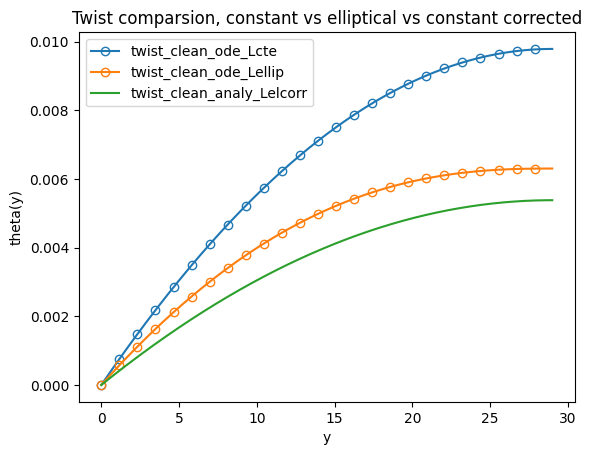

In [ ]:
Theta = (np.pi/4)*(1-2*lambd*b/np.pi)

def twist_analy_corr(x):
    return theta_wing_analy(x)*Theta

# Comparing constant vs elliptical vs corrected lift twist (y)
fig1 = plt.figure(1)

# Plot the twist ode clean constant lift distribution
plt.plot(x_plot, result_clean_simpl.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_Lcte', markevery=40, markerfacecolor='none')

# Plot the twist ode clean elliptic lift distribution
plt.plot(x_plot, result_clean_ellip.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_Lellip', markevery=40, markerfacecolor='none')

# Plot the twist analytical clean corrected constant (to mimic elliptical) lif distribution
plt.plot(x_plot, twist_analy_corr(x_plot),
         label='twist_clean_analy_Lelcorr', markevery=40, markerfacecolor='none')
plt.title('Twist comparsion, constant vs elliptical vs constant corrected')
plt.xlabel('y')
plt.ylabel('theta(y)')
plt.legend()

As a first assumption, scaling the twist $ \Theta^2 = \int_{0}^b \sqrt{1-y^2}/b = \pi/4 $ with the average lift gives a better approximation. This correction relies on the assumption that $\lambda b \ll \pi/2$. If we go back to the solution in equation 29.9, if $\lambda b \leq \pi/2$ then the solution either becomes negative, or starts oscillating, which should not occur in real wings.

The issue becomes for greater values for $\lambda$. We can plot the relative error between the twist for the elliptical lift distribution and the corrected twist.

## Relative error at the wingtip for several values of $\lambda$



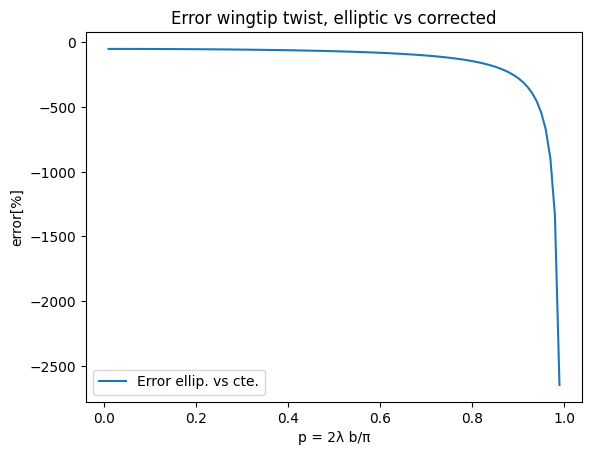

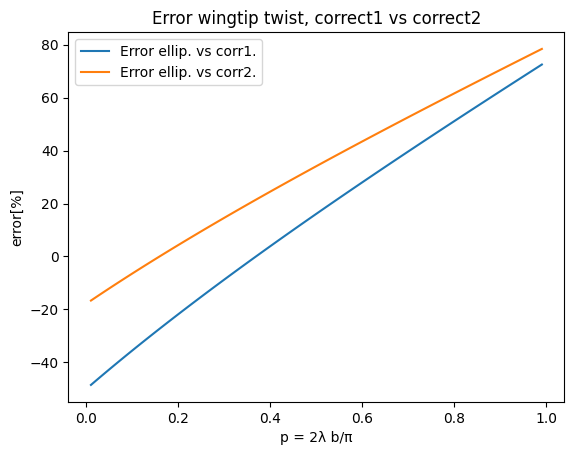

In [ ]:
lamdaP = np.linspace(0.01, 0.99, 100)

error = []
errorCorr = []
errorCorr2 = []

def ode_system_clean_ellip_Loop(x, y, alpha, gamma, lambd, b):
    rhsEq = -lambd**2*(y[0] + alpha + gamma)*np.sqrt(1-(x**2)/(b**2))
    return np.vstack((y[1], rhsEq))
def theta_wing_analy_Loop(x, alpha, gamma, lambd, b):
    return (alpha + gamma)*((np.cos(lambd*(b-x)))/np.cos(lambd*b) - 1)

for p in lamdaP:

    # Dynamic Pressure * ec² * dclda / GJ
    lambdLoop = p * (np.pi/2)/b # lambda * b < pi/2

    ### Corrected lift twist
    Theta = (np.pi/4)

    result_clean_ellipLoop = solve_bvp(lambda x,y: ode_system_clean_ellip_Loop(x,y, alpha, gamma, lambdLoop, b), bc, x_values, y_values)

    error.append(((result_clean_ellipLoop.sol(x_plot)[0][-1] - theta_wing_analy_Loop(x_plot[-1], alpha, gamma, lambdLoop, b))
                 / result_clean_ellipLoop.sol(x_plot)[0][-1]) * 100 )
    errorCorr.append(((result_clean_ellipLoop.sol(x_plot)[0][-1] - theta_wing_analy_Loop(x_plot[-1], alpha, gamma, lambdLoop, b)*(1-p))
                 / result_clean_ellipLoop.sol(x_plot)[0][-1]) * 100 )
    errorCorr2.append(((result_clean_ellipLoop.sol(x_plot)[0][-1] - theta_wing_analy_Loop(x_plot[-1], alpha, gamma, lambdLoop, b)*Theta*(1-p))
                 / result_clean_ellipLoop.sol(x_plot)[0][-1]) * 100 )

# Comparing constant vs elliptical vs corrected lift twist (y)
fig1 = plt.figure(1)
# Plot the error as a function of lambda
plt.plot(lamdaP, error, label='Error ellip. vs cte.')

plt.title('Error wingtip twist, elliptic vs corrected')
plt.ylabel('error[%]')
plt.xlabel('p = 2λ b/π')
plt.legend()

fig2 = plt.figure(2)
# Plot the error as a function of lambda
plt.plot(lamdaP, errorCorr, label='Error ellip. vs corr1.')
plt.plot(lamdaP, errorCorr2, label='Error ellip. vs corr2.')

plt.title('Error wingtip twist, correct1 vs correct2')
plt.ylabel('error[%]')
plt.xlabel('p = 2λ b/π')
plt.legend()

As it can be seen in the first figure, the relative error grows exponentially as $\lambda$ grows. This can be mitigated by correcting with lambda itself. Becoming:
$$ \theta(y) = \Theta \left(1- \frac{2b}{\pi}\lambda \right) (\alpha + \gamma) \left[ \frac{cos( \lambda (b - y))}{cos(\lambda  b)} -1 \right] $$

This is still work in progress.

# Aeroelastic effect of control surfaces

Again parting from T.H.G. Megson:

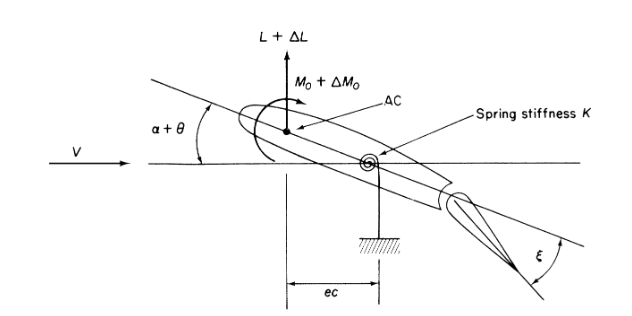

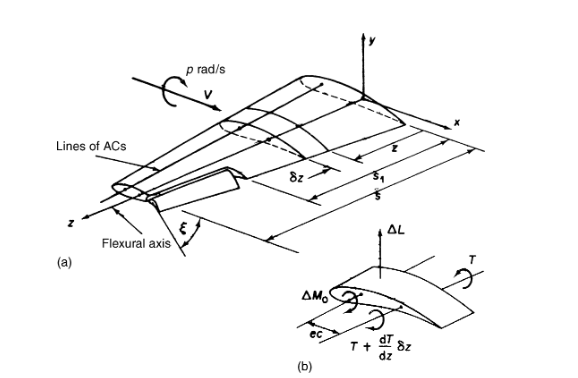



Now that we've defined a solution that approximates the aeroelastic behavior, we want to introduce the effect of control surfaces.

A control surface can be modeled as a linear contribution that can be added to the lift distribution, of the form (3):

$$ \Delta C_l(y) = \left[ \frac{\partial C_l}{\partial \alpha} (\alpha + \theta(y)) \sqrt{1-\frac{y^2}{b^2}} + \frac{\partial C_l}{\partial \epsilon} f_a(y) \epsilon \right] \delta y $$

And for the moment:

$$ \Delta C_{m,0}(y) = \left[ C_{m,0} \frac{\partial C_{m,0}}{\partial \epsilon} f_a(y)\epsilon \right] \delta y $$

Where $ f_a(y) $ is the activation function, that outputs 1 when $y$ is in the region of the control surface, that is:

$$ f_a(y)=   \left\{
\begin{array}{ll}
      0 & y < s_1 \\
      1 & s_1 \leq y \leq s_2 \\
      0 & s_2 < y \\
\end{array}
\right.  $$

Where $s1$ and $s2$ are the start and end of the control surface respectively. To make it always consistent the change of variable $ s1 = p - t/2$ and $ s2 = p + t/2 $. Which will leave the control surface definition as the position $p$ and size $t$.

This function $f_a(y)$ is not continuous. To be able to include it in equation (3) we need an approximation. In this case the sigmoid activation function is used:

$$ f_a(y) = \frac{1}{1+e^{a(s1-y)}} - \frac{1}{1+e^{a(s2-y)}}$$

Where $a$ is a constant that sets the slope of the activation function. A value of 1000 for a semispan of 1m seems sufficient...

In [ ]:
t = 0.2
p = 0.85

# Change of variable, in this manner s1 <= s2 always
s1 = (p - t/2)*b
s2 = (p + t/2)*b

a = 200/b # Sigmoid slope, dependent on b

Activation functions (use interchangably)

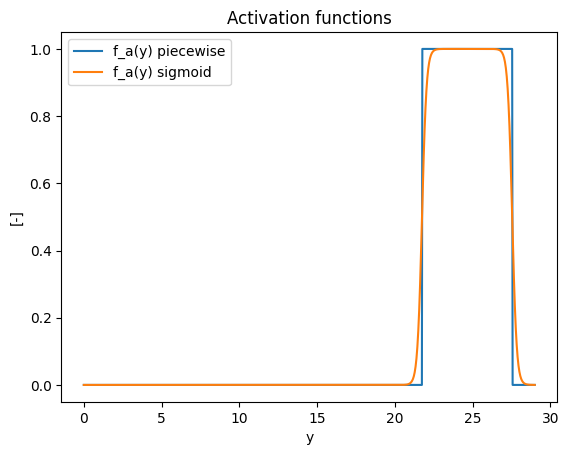

In [ ]:
def sigmoid(x,s):
    return 1 / (1 + np.exp(a*(s-x)))

def f_act_sigmoid(x):
    return sigmoid(x,s1) - sigmoid(x,s2)

# Just for fun it is possible also to compare wiht the piecewise activation function
def f_act_piecew(x):
    return np.asanyarray([1 if s1 <= x_i <= s2 else 0 for x_i in x])

# Plot the sigmoid activation function compared to the piecewise
plt.plot(x_plot, f_act_piecew(x_plot), label='f_a(y) piecewise')
plt.plot(x_plot, f_act_sigmoid(x_plot), label='f_a(y) sigmoid')

plt.title('Activation functions')
plt.xlabel('y')
plt.ylabel('[-]')
plt.legend()

Now equation (1) becomes:

$$ \frac{d^2\theta}{dy^2} + \lambda^2 \left[ \alpha + \theta(y) + \gamma + (\eta + \phi)f_a(y) \xi \right] = 0 $$

Where $ \xi $ is the control surface deflection, and:

$$ \eta = \frac{\partial C_l / \partial \xi}{\partial c_l / \partial \alpha} $$

$$ \gamma = \frac{C_{m,0}}{(\partial C_l / \partial \alpha) e} $$

$$ \phi = \frac{\partial C_{m,0} / \partial \xi}{(\partial C_l / \partial \alpha) e} $$

## Comparison of the Aileron effect on twist

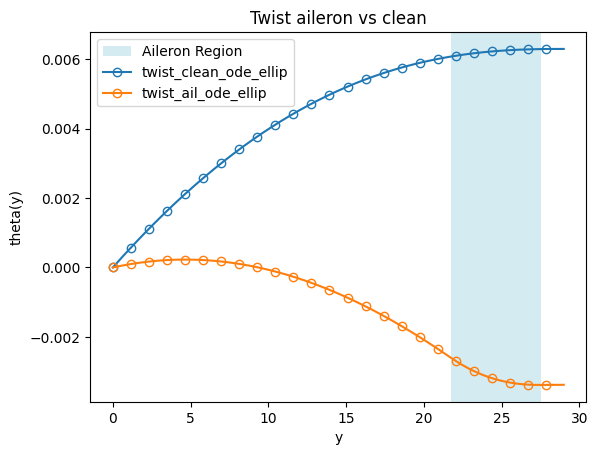

In [ ]:
# Define system with control surfaces

eta = 0.1 # dclde/dclda Aileron lift slope
phi = 1.5 # dcm0de/dclda Aileron moment
xi = -0.3 # Aileron deflection (Negative is upwards)

def ode_system_ail_const(x, y):
    rhsEq = -lambd**2*(alpha + y[0] + gamma + (eta + phi)*f_act_sigmoid(x)*xi )
    return np.vstack((y[1], rhsEq))

def ode_system_ail_ellip(x, y):
    rhsEq = -lambd**2*((alpha + y[0] + gamma + (eta + phi)*f_act_sigmoid(x)*xi )*np.sqrt(1-(x**2)/(b**2)))
    return np.vstack((y[1], rhsEq))

result_ail_const = solve_bvp(ode_system_ail_const, bc, x_values, y_values)
result_ail_ellip = solve_bvp(ode_system_ail_ellip, bc, x_values, y_values)

fig1 = plt.figure(1)
plt.axvspan(s1, s2, facecolor='lightblue', alpha=0.5, label='Aileron Region')

# Plot clean twist with constant lift distrib
#plt.plot(x_plot, result_clean_simpl.sol(x_plot)[0], marker='o',
#         label='twist_clean_ode_const', markevery=40, markerfacecolor='none')

# Plot aileron twist with constant lift distrib
#plt.plot(x_plot, result_ail_const.sol(x_plot)[0], marker='o',
#         label='twist_ail_ode_cte', markevery=40, markerfacecolor='none')

# Plot clean twist with elliptic lift distrib
plt.plot(x_plot, result_clean_ellip.sol(x_plot)[0], marker='o',
         label='twist_clean_ode_ellip', markevery=40, markerfacecolor='none')

# Plot aileron twist with elliptic lift distrib
plt.plot(x_plot, result_ail_ellip.sol(x_plot)[0], marker='o',
         label='twist_ail_ode_ellip', markevery=40, markerfacecolor='none')

plt.title('Twist aileron vs clean')
plt.xlabel('y')
plt.ylabel('theta(y)')
plt.legend()

The results show an increase in twist for the given $\lambda$, this can lead to control reversal. Well check afterwards...

## Derivation of wing + aileron twist equation

From the book T.H.G. Megson Aircraft, the equation (29.29):

> <div class="alert alert-block alert-danger">
<b>Wrong:</b>

$$ \theta(y) = \frac{p}{V} \left( y - \frac{\sin{\lambda y}}{\lambda \cos{\lambda b}} \right) - \frac{1}{\partial c_l / \partial \alpha} \left( \frac{\partial c_l}{\partial \xi} + \frac{1}{e} \frac{\partial C_{m,0}}{\partial \xi} \right) \left[ f_a(y) \left(1 - \cos{\lambda(y - s_1)}\right) - \frac{\sin{\lambda(b -s1)}}{\cos{\lambda b}} \sin{\lambda y} \right] \xi$$

</div>


Which, correct me if I'm wrong, I believe it should be:

> <div class="alert alert-block alert-success">
<b>Correct:</b>


$$ \theta(y) = \frac{p}{V} \left( \frac{\cos{\lambda(b-y)}}{\cos{\lambda b}} -1 \right) - \frac{1}{\partial c_l / \partial \alpha} \left( \frac{\partial c_l}{\partial \xi} + \frac{1}{e} \frac{\partial C_{m,0}}{\partial \xi} \right) \left[ f_a(y) \left(1 - \cos{\lambda(y - s_1)}\right) - \frac{\sin{\lambda(b -s1)}}{\cos{\lambda b}} \sin{\lambda y} \right] \xi$$

</div>

This equation uses the activation function of the type $f_a(x<s1) = 0$ and $ f_a(x\geq s1)= 1 $. We can adapt it so the aileron has a starting point ($s_1$) and an end position ($s_2$), then it becomes:

$$ \theta(y) = (\alpha + \gamma) \left( \frac{\cos{\lambda(b-y)}}{\cos{\lambda b}} -1 \right) - (\eta + \psi) \left[ \left[ f_{a1} ( 1 - \cos{ \lambda (y - s_1)} ) - f_{a2} (1 - \cos{ \lambda (y - s_2)}) \right] - \frac{\sin{\lambda y}}{\cos{\lambda b }} \left[ \sin{ \lambda (b - s_1)} - \sin{ \lambda (b - s_2)} \right] \right] $$

Where $f_{a1}(x<s1) = 0$ and $ f_{a1}(x\geq s1) = 1 $ and $f_{a2}(x<s1) = 0$ and $ f_{a2}(x\geq s1) = 1 $


Which is equal to a function that adds the twist of a clean wing, plus an aileron that starts at $s_1$ to the tip and substracting that same aileron but this time from $s_2$. Any kind of activation function works with this equation.

## Compare the analytical and numerical integrated twist equation

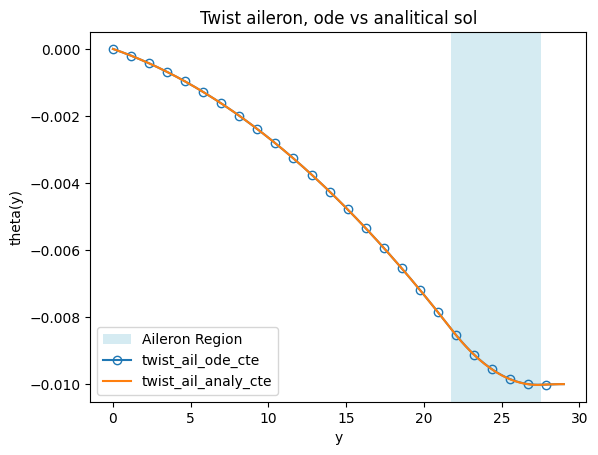

In [ ]:
def ode_aileron(x, y):
    rhsEq = -lambd**2*(alpha + y[0] + gamma + (eta + phi)*f_act_sigmoid(x)*xi)
    return np.vstack((y[1], rhsEq))

def f_act_s(x,s):
    return np.asanyarray([1 if s <= x_i else 0 for x_i in x])

def analy_sol_final(x):
    clean = np.cos(lambd*(b - x))/np.cos(lambd * b) - 1
    ail_fa = sigmoid(x, s1) * (1 - np.cos(lambd * (x - s1))) - sigmoid(x, s2) * (1 - np.cos(lambd * (x - s2)))
    ail_cte = - (np.sin(lambd * x)/ np.cos(lambd * b)) * (np.sin(lambd * (b - s1)) - np.sin(lambd*(b - s2)))

    return (alpha + gamma) * clean  - (eta + phi) * (ail_fa + ail_cte) * xi

result_ode_aileron = solve_bvp(ode_aileron, bc, x_values, y_values)

# Plot and compare the analytical solution to the ode (cte lift distrib)
fig1 = plt.figure(1)
plt.axvspan(s1, s2, facecolor='lightblue', alpha=0.5, label='Aileron Region')
plt.plot(x_plot, result_ode_aileron.sol(x_plot)[0], marker='o', label='twist_ail_ode_cte', markevery=40, markerfacecolor='none')
plt.plot(x_plot, analy_sol_final(x_plot), label='twist_ail_analy_cte', markevery=40, markerfacecolor='none')
plt.title('Twist aileron, ode vs analitical sol')
plt.xlabel('y')
plt.ylabel('theta(y)')
plt.legend()


## Derivate the new lift distribution with flexibility effects (aileron + wing)

So finally the equation for the lift distribution for a given aileron size ($t$) and position ($p$) is given by:

$$ C_l(y) = \frac{\partial C_l}{\partial \alpha} (\alpha + \theta(y)) \sqrt{1-\frac{y^2}{b^2}} + \frac{\partial C_l}{\partial \epsilon} f_a(y) \xi $$

Nondimensionalized with $\partial Cl / \partial \alpha$:

$$ \tilde{C}_l(y) = (\alpha + \theta(y)) \sqrt{1-\frac{y^2}{b^2}} + \eta f_a(y) \xi $$

where $\theta(y)$ is given by:

$$ \theta(y) = \left[\theta_{wing}(y) + \theta_{ail}(y) \right] $$

Where:

$$ \theta_{wing}(y) = (\alpha + \gamma) \left( \frac{\cos{ \lambda (b - y)}}{\cos{\lambda b}} - 1 \right)$$

and:
$$ \theta_{ail}(y) = -(\eta + \phi) \left\{ \left[ f_{a}(y,s_1) ( 1 - \cos{ \lambda (y - s_1)} ) - f_{a}(y,s_2) (1 - \cos{ \lambda (y - s_2)}) \right] - \frac{\sin{\lambda y}}{\cos{\lambda b }} \left[ \sin{ \lambda (b - s_1)} - \sin{ \lambda (b - s_2)} \right] \right\} \xi$$

where $\alpha$ is the angle of attack, $\xi$ is the aileron deflection, $b$ is the wing semispan and:

$$ \lambda^2 = \frac{1/2 \rho V^2 ec^2 \partial C_l / \partial \alpha}{GJ} \quad \gamma = \frac{C_{m,0}}{(\partial C_l / \partial \alpha)e} \quad \eta = \frac{\partial C_l / \partial \xi}{\partial C_l / \partial \alpha} \quad \psi = \frac{\partial C_{m,0} / \partial \xi }{ (\partial C_l / \partial \alpha)e } $$

And $f_{a}(y,s)$ can be either:

$$ f_a(y,s) = \frac{1}{1+e^{-a(y-s)}}$$

or in piecewise form:

$$ f_a(y,s)=   \left\{
\begin{array}{ll}
      0 & y < s \\
      1 & s \leq y \\
\end{array}
\right.  $$

As you might have guessed, the twist distribution $\theta(y)$ assumes a constant lift distribution wich introduces an error. This error can be mitigated with a correction factor, but as it is not linear it is dependant on the aero-flexibility factor $\lambda$.


## Plot the flexible lift distribution with and without aileron

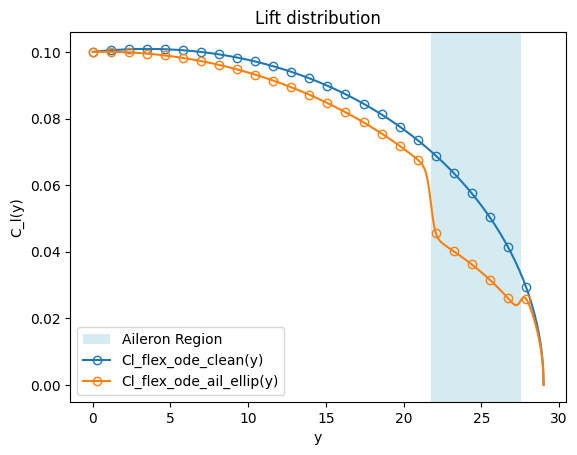

In [ ]:
# Define the range of x and y values for the solution
x_domain = np.linspace(0, b, 1000)
y_domain = np.zeros((2,x_domain.size))  # Change as needed, initial guess values

# Twist options
def theta_total_ail_cte(x_values):
    return solve_bvp(ode_system_ail_const, bc, x_values, y_domain).sol(x_values)[0]

def theta_total_ail_ellip(x_values):
    return solve_bvp(ode_system_ail_ellip, bc, x_values, y_domain).sol(x_values)[0]

def theta_total_clean_ellip(x_values):
    return solve_bvp(ode_system_clean_ellip, bc, x_values, y_domain).sol(x_values)[0]

# Lift distributions
def cl_flex_ode_clean_ellip(x):
    return (alpha + theta_total_clean_ellip(x))*np.sqrt(1-(x**2/b**2))

def cl_flex_ode_ail_ellip(x):
    return (alpha + theta_total_ail_ellip(x) + eta*f_act_sigmoid(x)*xi)*np.sqrt(1-(x**2/b**2))

def cl_rigid_analy_clean_ellip(x):
    return (alpha)*np.sqrt(1-(x**2/b**2))

def cl_rigid_analy_ail_ellip(x):
    return (alpha + eta*f_act_sigmoid(x)*xi)*np.sqrt(1-(x**2/b**2))


# Plot and compare the lift distributions
plt.axvspan(s1, s2, facecolor='lightblue', alpha=0.5, label='Aileron Region')

# Plot rigid clean Cl distrib
#plt.plot(x_plot, cl_rigid_analy_clean_ellip(x_plot), label='Cl_rigid_analy_clean_ellip(y)',
#         markevery=40, markerfacecolor='none')

# Plot rigid ail Cl distrib
#plt.plot(x_plot, cl_rigid_analy_ail_ellip(x_plot), label='Cl_rigid_analy_ail_ellip(y)',
#         markevery=40, markerfacecolor='none')

# Plot flex clean Cl distrib
plt.plot(x_plot, cl_flex_ode_clean_ellip(x_plot), marker='o',
         label='Cl_flex_ode_clean(y)',
         markevery=40, markerfacecolor='none')

# Plot flex ail Cl distrib
plt.plot(x_plot, cl_flex_ode_ail_ellip(x_plot), marker='o',
         label='Cl_flex_ode_ail_ellip(y)',
         markevery=40, markerfacecolor='none')

plt.title('Lift distribution')
plt.xlabel('y')
plt.ylabel('C_l(y)')
plt.legend()

As it can be seen there is a loss in lift, not only due to the aileron deployement, but also due to the twist induced by it. This loss in lift must be compensated by an increase in angle of attack to satisfy the equilibrium constraints.

## Loads integration

Now the next challenge is to integrate this lift distribution to compute the wing bending moment.

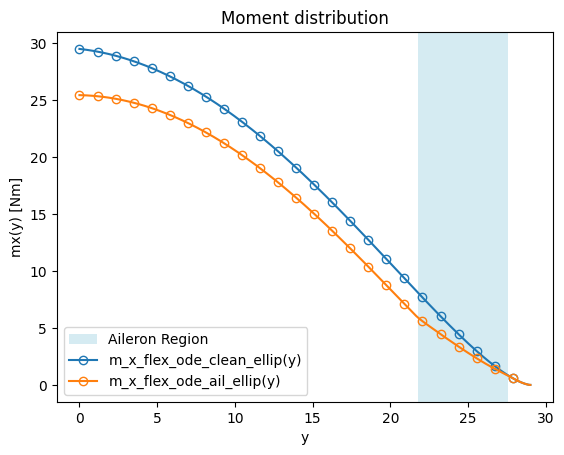

In [ ]:
import scipy.integrate as integrate

def m_x_flex_ode_clean_ellip(x):
    return cl_flex_ode_clean_ellip(x)*x

def m_x_flex_ode_ail_ellip(x):
    return cl_flex_ode_ail_ellip(x)*x

def int_m_x(xDom, mx_func):
    result = np.zeros_like(xDom)
    for i in range(xDom.size):
        domain = np.linspace(xDom[i] if xDom[i] != b else xDom[-2], b, 1000)
        result[i] = integrate.simpson(mx_func(domain), x=domain)
    return result

# Plot and compare the integrated moment distribution
plt.axvspan(s1, s2, facecolor='lightblue', alpha=0.5, label='Aileron Region')

# Plot the integrated moment for m_x_flex_ode_clean_ellip
plt.plot(x_domain, int_m_x(x_domain, m_x_flex_ode_clean_ellip),
         marker='o', label='m_x_flex_ode_clean_ellip(y)', markevery=40,
         markerfacecolor='none')

# Plot the integrated moment for m_x_flex_ode_ail_ellip
plt.plot(x_domain, int_m_x(x_domain, m_x_flex_ode_ail_ellip),
         marker='o', label='m_x_flex_ode_ail_ellip(y)', markevery=40,
         markerfacecolor='none')

plt.title('Moment distribution')
plt.xlabel('y')
plt.ylabel('mx(y) [Nm]')
plt.legend()

But this is at a given AoA, to fully represent the MLA the lift is constant. Which means that alpha is no longer constant.

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.7313643323468852e-06
            Iterations: 5
            Function evaluations: 23
            Gradient evaluations: 5


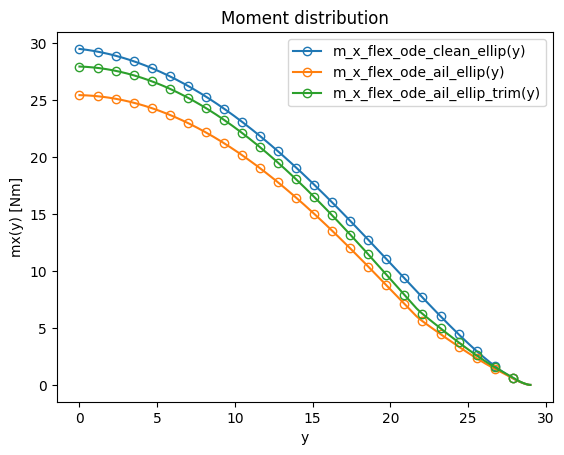

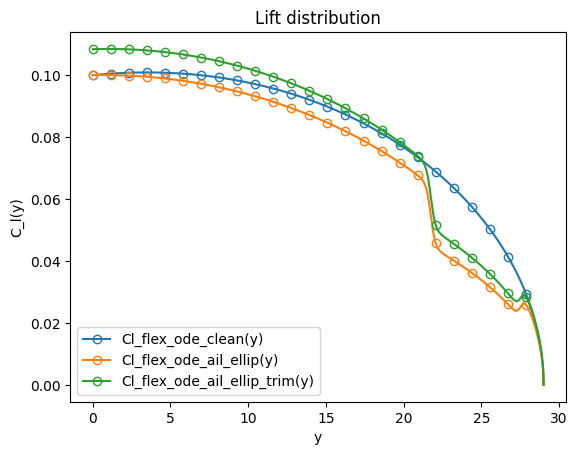

In [ ]:
from scipy.optimize import minimize

# Integrate total Cl
def int_cl(xDom, cl_func):
    return integrate.simpson(cl_func(xDom), x=xDom)

# To perform MLA the total lift we have in the clean conf must be conserved once
# the aileron is deployed, and thus we have out target lift.
CLLift_flex_clean = int_cl(x_domain, cl_flex_ode_clean_ellip)

# New functions with alpha as input

def ode_system_ail_trim_ellip(x, y, alphaTrim):
    rhsEq = -lambd**2*((alphaTrim + y[0] + gamma + (eta + phi)*f_act_sigmoid(x)*xi)
    *np.sqrt(1-(x**2)/(b**2)))

    return np.vstack((y[1], rhsEq))

def theta_trim_total_ail_ellip(x_values, alphaTrim):
    y_domain = np.zeros((2,x_values.size))
    return solve_bvp(lambda x,y: ode_system_ail_trim_ellip(x,y, alphaTrim),
                     bc, x_values, y_domain).sol(x_values)[0]

def cl_trim_flex_analy_ail_ellip(x_values, alphaTrim):
    return (alphaTrim + theta_trim_total_ail_ellip(x_values, alphaTrim) +
            eta*f_act_sigmoid(x_values)*xi)*np.sqrt(1-(x_values**2/b**2))

def trimCL(alphaTrim, clTarget, x_values, clFunc):
    return np.abs(integrate.simpson(clFunc(x_values, alphaTrim), x=x_values) -clTarget)

# Obtain the new alpha value that gives the same total lift
res = minimize( lambda alphaTr: trimCL(alphaTr, CLLift_flex_clean, x_values,
                                       cl_trim_flex_analy_ail_ellip), alpha,
                                        method='SLSQP', options={'disp': True})
alphaTrim = res.x

# Define the new moment distribution
def m_x_flex_ode_ail_ellip_trim(x, alphaTrim):
    return cl_trim_flex_analy_ail_ellip(x, alphaTrim)*x

def int_m_x_trim(xDom, mx_func, alphaTrim):
    result = np.zeros_like(xDom)
    for i in range(xDom.size):
        domain = np.linspace(xDom[i] if xDom[i] != b else xDom[-2], b, 1000)
        result[i] = integrate.simpson(mx_func(domain, alphaTrim), x=domain)
    return result

# Integrate the moment and plot
fig1 = plt.figure(1)
# Plot the integrated moment for m_x_flex_ode_clean_ellip
plt.plot(x_domain, int_m_x(x_domain, m_x_flex_ode_clean_ellip),
         marker='o', label='m_x_flex_ode_clean_ellip(y)', markevery=40,
         markerfacecolor='none')

# Plot the integrated moment for m_x_flex_ode_ail_ellip
plt.plot(x_domain, int_m_x(x_domain, m_x_flex_ode_ail_ellip),
         marker='o', label='m_x_flex_ode_ail_ellip(y)', markevery=40,
         markerfacecolor='none')

# Plot the integrated moment for m_x_flex_ode_ail_ellip_trim
plt.plot(x_domain, int_m_x_trim(x_domain, m_x_flex_ode_ail_ellip_trim, alphaTrim),
         marker='o', label='m_x_flex_ode_ail_ellip_trim(y)', markevery=40,
         markerfacecolor='none')

plt.title('Moment distribution')
plt.xlabel('y')
plt.ylabel('mx(y) [Nm]')
plt.legend()

# Plot also the lift distribution
fig2 = plt.figure(2)
# Plot flex clean Cl distrib
plt.plot(x_plot, cl_flex_ode_clean_ellip(x_plot), marker='o',
         label='Cl_flex_ode_clean(y)',
         markevery=40, markerfacecolor='none')

# Plot flex ail Cl distrib
plt.plot(x_plot, cl_flex_ode_ail_ellip(x_plot), marker='o',
         label='Cl_flex_ode_ail_ellip(y)',
         markevery=40, markerfacecolor='none')

# Plot flex ail Cl distrib in trim (i.e. CL clean == CL ail)
plt.plot(x_plot, cl_trim_flex_analy_ail_ellip(x_plot, alphaTrim), marker='o',
         label='Cl_flex_ode_ail_ellip_trim(y)', markevery=40, markerfacecolor='none')

plt.title('Lift distribution')
plt.xlabel('y')
plt.ylabel('C_l(y)')
plt.legend()

As it can be seen, although we had to increase the angle of attack to preserve the total lift, the bending moment is still reduced at the root.

## Loads optimization through aileron placement

The final step is to transform everything into a formula as a function of the aileron position, and to further understand the effects of flexibility it must be also dependent on $\lambda$.
$$ \begin{align}
  {\rm Minimize}   && M_x(p) \nonumber \\
  {\rm w.r.t.}     && \text{p} \nonumber \\
  {\rm subject~to} && 0 < p/b < 1 \nonumber \\
  {\rm and} && L(\alpha) = W \nonumber
\end{align} $$

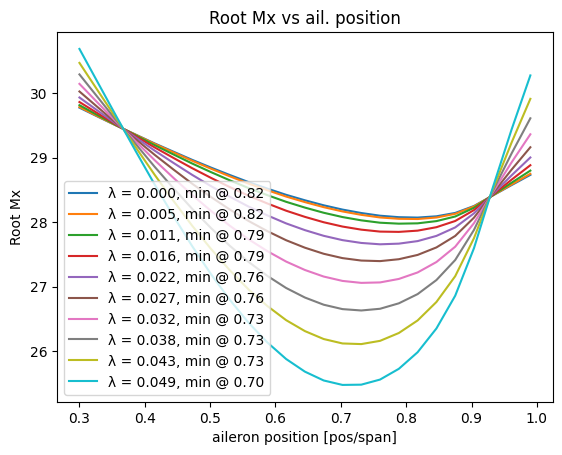

In [ ]:
def sigmoid_opt(x, s, a):
    return 1 / (1 + np.exp(a*(s-x)))

def f_act_sigmoid_opt(x, b, pos, taille):
    # Change of variable, in this manner s1 <= s2 always
    s1 = (pos - taille/2)*b
    s2 = (pos + taille/2)*b

    a = 200/b # Sigmoid slope, dependent on b
    return sigmoid_opt(x, s1, a) - sigmoid_opt(x, s2, a)

def ode_system_ail_ellip_opt(x, y, alpha, gamma, lambd, eta, phi, xi, b, pos, taille):
    rhsEq = -lambd**2*((alpha + y[0] + gamma + (eta + phi)*f_act_sigmoid_opt(x, b, pos, taille)*xi )*np.sqrt(1-(x**2)/(b**2)))
    return np.vstack((y[1], rhsEq))

def theta_total_ail_ellip_opt(x_values, alpha, gamma, lambd, eta, phi, xi, b, pos, taille):
    y_domain = np.zeros((2,x_values.size))
    return solve_bvp(lambda x,y: ode_system_ail_ellip_opt(x, y, alpha, gamma, lambd, eta, phi, xi, b, pos, taille),
                     bc, x_values, y_domain).sol(x_values)[0]

def cl_flex_ode_ail_ellip_opt(x, alpha, gamma, lambd, eta, phi, xi, b, pos, taille):
    return (alpha + theta_total_ail_ellip_opt(x, alpha, gamma, lambd, eta, phi, xi, b, pos, taille) +
            eta*f_act_sigmoid_opt(x, b, pos, taille)*xi)*np.sqrt(1-(x**2/b**2))

def trimCL_opt(alphaTrim, ClTarget, x_values, clFunc, gamma, lambd, eta, phi, xi, b, pos, taille):
    return np.abs(integrate.simpson(clFunc(x_values, alphaTrim, gamma, lambd, eta, phi, xi, b, pos, taille), x=x_values) -ClTarget)

def m_x_flex_ode_ail_ellip_opt(x, alpha, gamma, lambd, eta, phi, xi, b, pos, taille):
    return cl_flex_ode_ail_ellip_opt(x, alpha, gamma, lambd, eta, phi, xi, b, pos, taille)*x

def int_Mx_opt_trim(xDom, mx_func, gamma, lambd, eta, phi, xi, b, CLTarget, pos, taille):

    res = minimize( lambda alphaTr: trimCL_opt(alphaTr, CLTarget, x_values,
                                               cl_flex_ode_ail_ellip_opt,
                                               gamma, lambd, eta, phi, xi, b, pos, taille),
                                                alpha,method='SLSQP')
    alphaTrim = res.x
    return integrate.simpson(mx_func(xDom, alphaTrim, gamma, lambd, eta, phi, xi, b, pos, taille), x=xDom)

linspacePos = np.linspace(0.3, 0.99, 25)
linspaceLambda = np.linspace(0, 0.9, 10) * (np.pi/2)/b

taille = t # Nondimensional [taille [m]/ span [m]]

for lambd_i in linspaceLambda:
    totMx_vs_Pos = []
    for pos_i in linspacePos:
        totMx_vs_Pos.append(int_Mx_opt_trim(x_domain, m_x_flex_ode_ail_ellip_opt, gamma, lambd_i, eta, phi, xi, b, CLLift_flex_clean, pos_i, taille))

    # Find the minimum
    min_index = np.argmin(totMx_vs_Pos)
    minMx_x, minMx_y = linspacePos[min_index], totMx_vs_Pos[min_index]
    # Plot total moment as a function of the aileron position
    plt.plot(linspacePos, totMx_vs_Pos,
            label='λ = %.3f, min @ %.2f' % (lambd_i, minMx_x),
             markevery=40, markerfacecolor='none')

plt.title('Root Mx vs ail. position')
plt.xlabel('aileron position [pos/span]')
plt.ylabel('Root Mx')
plt.legend()

The curve is the same shape as the one shown at the beggining with a rigid wing and point load aileron. Another interesting parameter is $\lambda$, which is the ratio of the aero loads and the twist flexibility. Starting from $\lambda = 0$ which would represent a rigid wing, the result lies on an aileron placed at 82% with respect to the span. Once the wing becomes more flexible, the optima lies closer to the span. The greatest value of $\lambda$ is $0.9 \pi/(2b)$ which is very close to divergence.


## Nastran results

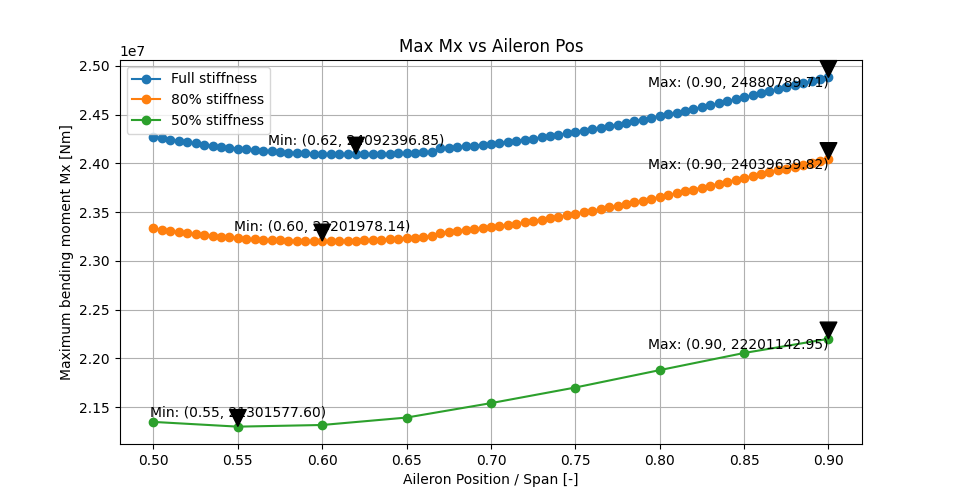

This quick and dirty plot shows the uCRM wingbox with the bending moment as a function of the aileron position, showing that if we wrere to reduce artificially the stiffness of the wing the optimal placement of the aileron will move inboard.